# Berlin EmoDB -> spectrogrammes RGB

Telecharge la base Berlin EmoDB et convertit chaque fichier wav en une image RGB de son mel-spectrogramme.

In [13]:
# deps (deja installees dans .venv, selectionner le kernel "Python (CNN_RO11 .venv)")
%pip install -q librosa matplotlib numpy soundfile pillow

Note: you may need to restart the kernel to use updated packages.


In [12]:
import io, zipfile, urllib.request
from pathlib import Path

import librosa
import numpy as np
from matplotlib import cm
from PIL import Image

URL = "http://emodb.bilderbar.info/download/download.zip"
RAW = Path("data/emodb")
OUT = Path("data/spectrograms")

# code emotion = 6eme caractere du nom de fichier (ex: 03a01Fa.wav -> F -> joie)
EMOTIONS = {
    "W": "anger", "L": "boredom", "E": "disgust", "A": "fear",
    "F": "happiness", "T": "sadness", "N": "neutral",
}

In [9]:
# 1. telechargement + extraction
if not RAW.exists():
    RAW.mkdir(parents=True)
    print("downloading...")
    data = urllib.request.urlopen(URL).read()
    zipfile.ZipFile(io.BytesIO(data)).extractall(RAW)

wavs = sorted(RAW.rglob("*.wav"))
print(len(wavs), "fichiers wav")

535 fichiers wav


In [14]:
# 2. wav -> mel-spectrogramme -> image RGB
SR = 16000
N_MELS = 128
SIZE = (224, 224)  # (largeur, hauteur) attendue par le CNN

def wav_to_rgb(path):
    y, sr = librosa.load(path, sr=SR)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=1024, hop_length=256, n_mels=N_MELS)
    db = librosa.power_to_db(mel, ref=np.max)
    norm = (db - db.min()) / (db.max() - db.min() + 1e-9)  # 0..1
    rgb = (cm.viridis(norm[::-1])[..., :3] * 255).astype(np.uint8)  # basses freq en bas
    return Image.fromarray(rgb).resize(SIZE, Image.BILINEAR)

for wav in wavs:
    label = EMOTIONS[wav.stem[5]]
    dest = OUT / label
    dest.mkdir(parents=True, exist_ok=True)
    wav_to_rgb(wav).save(dest / f"{wav.stem}.png")

print("images ecrites dans", OUT)

images ecrites dans data/spectrograms


.DS_Store 0
anger 127
boredom 81
disgust 46
fear 69
happiness 71
neutral 79
sadness 62


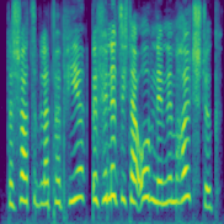

In [15]:
# 3. verification rapide
for d in sorted(OUT.iterdir()):
    print(d.name, len(list(d.glob("*.png"))))

display(Image.open(next(OUT.rglob("*.png"))))